In [1]:
import numpy as np
import json
import torch
import scipy
import torch.nn as nn  
from torch.utils.data import DataLoader, TensorDataset
from scipy.signal import savgol_filter
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import joblib
#==========Version Check===========
#==========Version Check===========
#==========Version Check===========
print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"scipy: {scipy.__version__}")
print(f"torch: {torch.__version__}")

torch.cuda.empty_cache()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

numpy: 1.26.4
pandas: 2.1.4
scipy: 1.12.0
torch: 2.2.0+cu121
Using device: cuda


In [2]:
#==========Model Class===========
#==========Model Class===========
#==========Model Class===========
class FlowPredictor(nn.Module):
    def __init__(self, hidden_dim, output_dim, dropout, input_dim=1):
        super(FlowPredictor, self).__init__()
        #Layer1
        self.lstm1 = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.dropout1 = nn.Dropout(dropout)
        
        #Layer2
        self.lstm2 = nn.LSTM(hidden_dim, hidden_dim // 2, batch_first=True)
        self.dropout2 = nn.Dropout(dropout)
        
        #Layer3
        self.lstm3 = nn.LSTM(hidden_dim // 2, hidden_dim // 4, batch_first=True)
        self.dropout3 = nn.Dropout(dropout)

        #Last layer
        self.fc = nn.Linear(hidden_dim // 4, output_dim)
        #self.fc = nn.Linear(hidden_dim // 2, output_dim)

    def forward(self, x):
        # x shape: (batch, seq_len, input_dim)
        lstm1_out, _ = self.lstm1(x)
        out = self.dropout1(lstm1_out)

        lstm2_out, _ = self.lstm2(lstm1_out)
        out = self.dropout2(lstm2_out)

        lstm3_out, _ = self.lstm3(lstm2_out)

        # Use the last hidden state for prediction
        last_hidden = lstm3_out[:, -1, :]
        out = self.dropout3(last_hidden)
        #last_hidden = lstm2_out[:, -1, :]
        #out = self.dropout2(last_hidden)
        out = self.fc(out)
        return out

In [27]:
#==========Params===========
#==========Params===========
#==========Params===========
#data slicing
start = 1440 * 0 # +1일차
if (start != 0):
    start = start-2
end = start + 1439 * 365 #일간
split_rate = 0.7 

#Sliding window config
window_size=180
forecast_size=15
lead_time=1 #forecast_size 보다 커지면 윈도우 사이에 갭이 생기므로 주의

#LSTM config
units = 32

#learning config
epochs=15
batch_size=128
lr=0.00280028 # < 0.08
dropout=0.542298
wd=1.37457e-05

In [28]:
#==========Data Load===========
#==========Data Load===========
#==========Data Load===========
resv_flow = pd.read_csv('../data/rawdata/53.csv')
resv_flow.columns = ['id', 'time', 'resv_flow', 'drop']
del resv_flow['id']
del resv_flow['drop']

resv_flow_temp = resv_flow[start:end]

time = resv_flow_temp['time']
time = pd.to_datetime(time)
resv_flow_temp['time'] = time

#==========Preprocessing & Normalization===========
#==========Preprocessing & Normalization===========
#==========Preprocessing & Normalization===========
resv_flow_temp['savgol_smooth'] = savgol_filter(resv_flow_temp['resv_flow'], window_length=31, polyorder=1)

scaler = MinMaxScaler(feature_range=(0,1))
column_to_normalize = resv_flow_temp.columns[-1]
resv_flow_temp['normalized_flow'] = scaler.fit_transform(resv_flow_temp[[column_to_normalize]])

#==========Create Sliding Windows===========
#==========Create Sliding Windows===========
#==========Create Sliding Windows===========
def create_slidinwindows(data, window_size=60, lead_time=1, forecast_size=10):
    #기존 분단위 슬라이딩 코드
    stop_index = len(data) - window_size - forecast_size# -lead_time
    X = [data[i:i+window_size] for i in range(stop_index)]
    y = [data[i+window_size : i+window_size+forecast_size] for i in range(stop_index)]
    
    #신규 lead_time분단위 슬라이딩 코드: 윈도우를 1분씩 뒤로 미는 것이 아니라 x분씩 뒤로 민다. 과도한 학습을 방지하기 위해 작성해보았음.
    #stop_index = int((len(data) - window_size - forecast_size)/lead_time)
    #X = [data[i*lead_time : i*lead_time+window_size] for i in range(stop_index)]
    #y = [data[i*lead_time+window_size : i*lead_time+window_size+forecast_size] for i in range(stop_index)]

    return np.array(X), np.array(y)

data = resv_flow_temp['normalized_flow'].values
X,y = create_slidinwindows(data=data, window_size=window_size, lead_time=lead_time, forecast_size=forecast_size)
X = X.reshape((X.shape[0], X.shape[1],1))

#==========Train Test Split===========
#==========Train Test Split===========
#==========Train Test Split===========
split_index = int(len(X) * split_rate)
print(split_index)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

#==========Conver it to Tensor===========
#==========Conver it to Tensor===========
#==========Conver it to Tensor===========
X_train, X_test, y_train, y_test = torch.FloatTensor(X_train), torch.FloatTensor(X_test), torch.FloatTensor(y_train), torch.FloatTensor(y_test)
    
#==========Execute Learning===========
#==========Execute Learning===========
#==========Execute Learning===========
#Univariate LSTM with MSE Loss
#Move the model and train/test data to CUDA
model = FlowPredictor(hidden_dim=units, output_dim=forecast_size, dropout=dropout).to(device)

# Wrap tensors into a Dataset object
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
# Create the DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) 
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

#mse_criterion = nn.MSELoss() # For MSE
mae_criterion = nn.L1Loss() # Equivalent to mean_absolute_error
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

#Learning
for epoch in range(epochs):
    model.train()

    runnintrain_loss = 0.0
    #Train
    for batch_X, batch_y in train_loader:
        # Move batch to CUDA
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass (Batch level)
        outputs = model(batch_X)
        loss = mae_criterion(outputs, batch_y)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        runnintrain_loss += loss.item()
    
    # Calculate average training loss for this epoch
    avmae_train = runnintrain_loss / len(train_loader)
    
    # Validation
    all_preds = []
    all_tests = []

    model.eval()
    total_mae_val = 0.0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            # Move ONLY the small batch to the GPU
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            outputs = model(batch_X)

            loss = mae_criterion(outputs, batch_y)
            total_mae_val += loss.item()

            # Move back to CPU and convert to list/numpy
            all_preds.append(outputs.cpu())
            all_tests.append(batch_y.cpu())

    average_mae_val = total_mae_val / len(test_loader)
    if(epoch+1) % 5 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], MAE Loss: {avmae_train:.4f}, MAE Val Loss: {average_mae_val:.4f}')

C:\Users\user\AppData\Local\Temp\ipykernel_11864\386712764.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  resv_flow_temp['time'] = time
C:\Users\user\AppData\Local\Temp\ipykernel_11864\386712764.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  resv_flow_temp['savgol_smooth'] = savgol_filter(resv_flow_temp['resv_flow'], window_length=31, polyorder=1)
C:\Users\user\AppData\Local\Temp\ipykernel_11864\386712764.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Dat

367528
Epoch [5/15], MAE Loss: 0.0384, MAE Val Loss: 0.0174
Epoch [10/15], MAE Loss: 0.0381, MAE Val Loss: 0.0138
Epoch [15/15], MAE Loss: 0.0382, MAE Val Loss: 0.0145


In [29]:
# Concatenate all batches into a single numpy array
y_pred_np = torch.cat(all_preds).numpy()
y_test_np = torch.cat(all_tests).numpy()


#==========Denormalize===========
#==========Denormalize===========
#==========Denormalize===========
y_pred_original = scaler.inverse_transform(y_pred_np.reshape(-1,1)).reshape(y_pred_np.shape)
y_test_original = scaler.inverse_transform(y_test_np.reshape(-1,1)).reshape(y_test_np.shape)

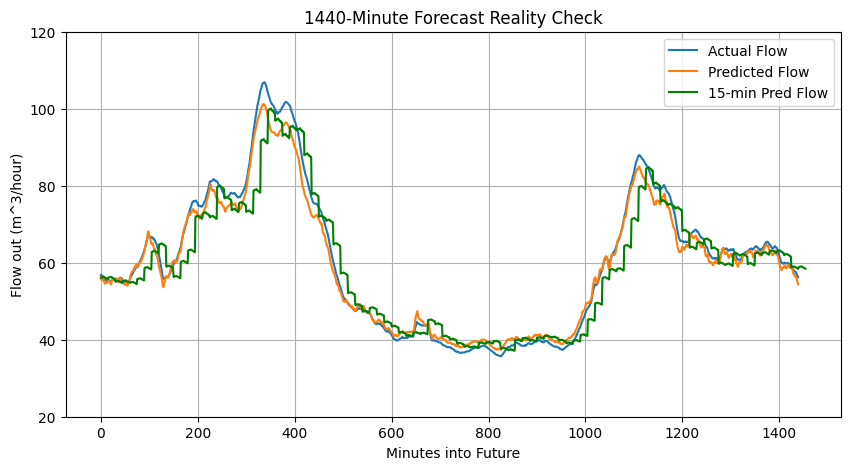

In [31]:
#==========Data Plot===========
#==========Data Plot===========
#==========Data Plot===========
sample_idx0 = 1440 * 0
interval = 60*24 #Max = total interval (minute) * 0.2
sample_idx1 = sample_idx0 + interval

y_test_flattened = y_test_original[:,0].flatten()
y_test_plot = y_test_flattened[sample_idx0 : sample_idx1]

y_pred_flattened = y_pred_original[:,5].flatten() #인덱스 적절하게 조정하기
y_pred_plot = y_pred_flattened[sample_idx0 : sample_idx1]

#Windows
y_pred2_plot = y_pred_original[0]
first_n_days = 1440 * 1
for i in range(first_n_days//forecast_size):
    y_pred2_plot = np.concatenate((y_pred2_plot,y_pred_original[i*forecast_size]))


plt.figure(figsize=(10, 5))


plt.plot(range(len(y_test_plot)), y_test_plot, label='Actual Flow')#, marker='o')
plt.plot(range(len(y_pred_plot)), y_pred_plot, label='Predicted Flow')#, marker='x')
plt.plot(range(len(y_pred2_plot)), y_pred2_plot, label=f'{forecast_size}-min Pred Flow', color='green')


plt.title(f"{interval}-Minute Forecast Reality Check")
plt.xlabel("Minutes into Future")
plt.ylabel("Flow out (m^3/hour)")
plt.legend()
plt.grid(True)
plt.ylim(20, 120) 
plt.show()

In [32]:
#==========Data Export===========
#==========Data Export===========
#==========Data Export===========
# y_pred_flattened = y_pred_original[:,5].flatten() #인덱스 적절하게 조정하기
# y_pred_export = np.concatenate( (y_pred_flattened, y_pred_original[-1]))

# resv_flow_export = resv_flow_temp[-1440:]

# y_accuracy = (1-np.abs(y_pred_original - y_test_original) / (y_test_original+1))
# y_accuracy_export = np.concatenate((y_accuracy[:,0], y_accuracy[-1]))

# del resv_flow_export['savgol_smooth']
# del resv_flow_export['normalized_flow']
# del resv_flow_export['resv_flow']
# resv_flow_export['resv_flow_pred'] = y_pred_export
# resv_flow_export['accuracy'] = y_accuracy_export


# # 1. Convert the DataFrame rows to a list of dictionaries
# json_data = resv_flow_export.to_json(orient='records', date_format='iso')
# json_date = resv_flow_export['time'].iloc[0].strftime("%Y-%m-%d")
# # 2. Parse that string back to a Python object and wrap it
# # (This step is necessary if you want the 'predictions' header)
# final_dict = {
#     "resv_flow_pred": json.loads(json_data)
# }

# # 3. Convert the final dictionary to a JSON string for Redis
# json_for_redis = json.dumps(final_dict)
# date_for_redis = json.dumps(json_date)
# print(date_for_redis)

#============Save Artifacts==============
#============Save Artifacts==============
#============Save Artifacts==============

# 1. Save the PyTorch Model Weights
# We move the model to CPU before saving to ensure it can be loaded even on servers without a GPU.
model.cpu()
torch.save(model.state_dict(), 'g_resv_flow_model.pth')

# 2. Save the Scaler
joblib.dump(scaler, 'g_resv_scaler.pkl')

# 3. Save the Hyperparams
hyperparams = {
"units": units,
"forecast_size": forecast_size,
"dropout": dropout
}

with open('g_resv_config.json', 'w') as f:
    json.dump(hyperparams, f)

print("Model and Scaler artifacts have been saved successfully.")

Model and Scaler artifacts have been saved successfully.
